In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten,Input
import pandas as pd

In [2]:
df = pd.read_csv("student-mat.csv",sep=';')

In [3]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [5]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [7]:

catergorical=df.select_dtypes(include='object').columns
print(catergorical)

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='str')


C:\Users\DELL\AppData\Local\Temp\ipykernel_10940\2997188017.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  catergorical=df.select_dtypes(include='object').columns


In [8]:
for i in catergorical:
  df[i]=le.fit_transform(df[i])
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,1,0,0,4,4,0,4,...,4,3,4,1,1,3,6,5,6,6
1,0,0,17,1,0,1,1,1,0,2,...,5,3,3,1,1,3,4,5,5,6
2,0,0,15,1,1,1,1,1,0,2,...,4,3,2,2,3,3,10,7,8,10
3,0,0,15,1,0,1,4,2,1,3,...,3,2,2,1,1,5,2,15,14,15
4,0,0,16,1,0,1,3,3,2,2,...,4,3,2,1,2,5,4,6,10,10


In [9]:
X = df.drop('G3',axis=1)
y = df['G3']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42)


print("Training:", X_train.shape)
print("Validation:", X_val.shape)

Training: (276, 32)
Validation: (59, 32)


In [11]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [12]:
model=Sequential([
Input(shape=(32,)),
Dense(128,activation='relu'),
Dense(64,activation='relu'),
Dense(32,activation='relu'),
Dense(1,activation='relu')])

In [13]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['r2_score']
    )

In [14]:
model.fit(X_train, y_train, 
          epochs=100,
          batch_size=32,
          validation_data=(X_test, y_test)
          )

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 120.9221 - r2_score: -4.9044 - val_loss: 101.6844 - val_r2_score: -4.0769
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 93.1645 - r2_score: -3.5491 - val_loss: 71.2751 - val_r2_score: -2.5586
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 59.6150 - r2_score: -1.9109 - val_loss: 38.4543 - val_r2_score: -0.9199
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 28.5050 - r2_score: -0.3918 - val_loss: 16.4440 - val_r2_score: 0.1790
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 16.9401 - r2_score: 0.1728 - val_loss: 14.0951 - val_r2_score: 0.2963
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 13.7802 - r2_score: 0.3271 - val_loss: 9.9990 - val_r2_score: 0.5008
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 9.3883 - r2_score: 0.5416 - val_loss: 8.7802 - val_r2_score: 0.5616
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 7.7123 - r2_score: 0.6234 - val_loss: 7.

In [15]:
pred=model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


In [16]:
from sklearn.metrics import r2_score
print("R2 Score:", r2_score(y_test, pred))

R2 Score: 0.685244619846344


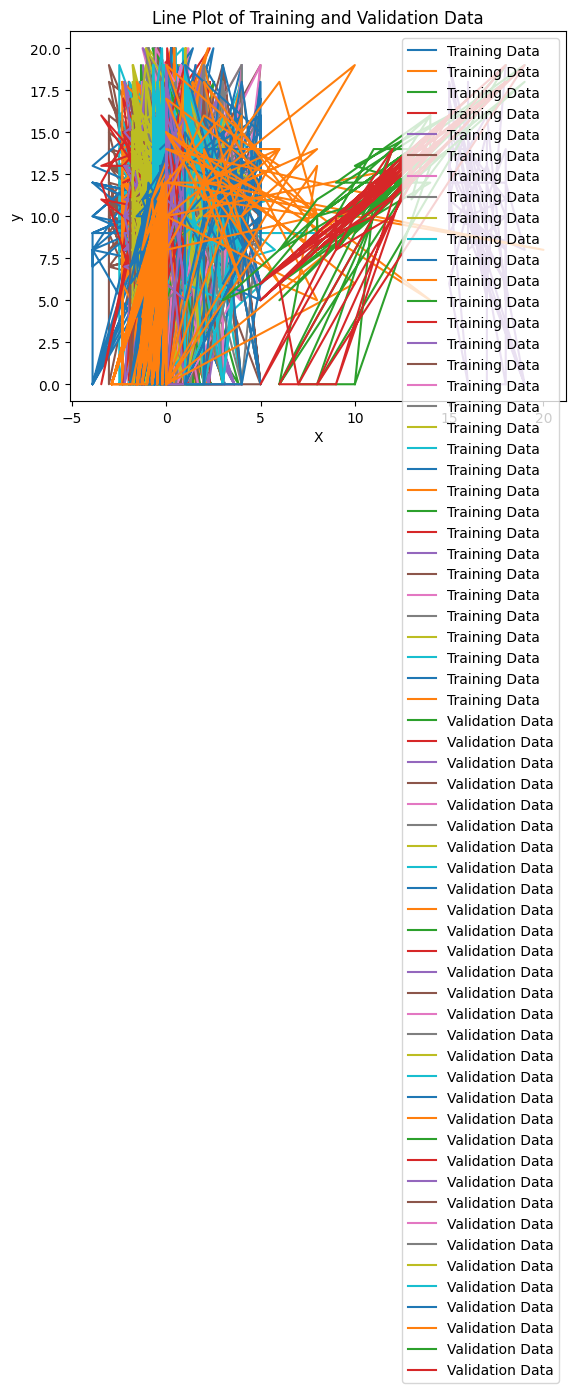

In [18]:
# line plot of train and validatinon data

plt.plot(X_train, y_train, label='Training Data')
plt.plot(X_val, y_val, label='Validation Data')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Line Plot of Training and Validation Data')
plt.legend()
plt.show()